# 01 — Exploratory Data Analysis

This notebook explores the Kaggle MCQ dataset and builds the shared feature matrices used by the downstream model notebooks. Run this first. It saves `train_long.parquet` and `test_long.parquet` under `../features/`.

In [22]:
import subprocess, sys
def _p(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
for pkg in ['sentence-transformers', 'pyarrow']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        _p(pkg)

In [23]:
import os
from pathlib import Path

IS_KAGGLE = os.path.exists("/kaggle/input")

if IS_KAGGLE:
    DATA_DIR = Path("/kaggle/input/competitions/smart-mcq-solver-challenge")
    OUTPUT_DIR = Path("/kaggle/working")
    PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
    FEATURES_DIR = OUTPUT_DIR / "features"
    FIGURES_DIR = OUTPUT_DIR / "figures"
else:
    ROOT = Path.cwd()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
    DATA_DIR = ROOT / "data"
    PREDICTIONS_DIR = ROOT / "predictions"
    FEATURES_DIR = ROOT / "features"
    FIGURES_DIR = ROOT / "figures"

for p in [PREDICTIONS_DIR, FEATURES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"IS_KAGGLE={IS_KAGGLE}")
print(f"DATA_DIR={DATA_DIR}")
print(f"PREDICTIONS_DIR={PREDICTIONS_DIR}")
print(f"FEATURES_DIR={FEATURES_DIR}")
print(f"FIGURES_DIR={FIGURES_DIR}")

IS_KAGGLE=False
DATA_DIR=c:\Users\Krishna\Downloads\dl-genai-t22026-23f2001849\data
PREDICTIONS_DIR=c:\Users\Krishna\Downloads\dl-genai-t22026-23f2001849\predictions
FEATURES_DIR=c:\Users\Krishna\Downloads\dl-genai-t22026-23f2001849\features
FIGURES_DIR=c:\Users\Krishna\Downloads\dl-genai-t22026-23f2001849\figures


In [24]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_style('whitegrid')
OPTIONS = ['A', 'B', 'C', 'D', 'E']

In [25]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample = pd.read_csv(DATA_DIR / 'sample_submission.csv')
print(f'train: {train.shape}, test: {test.shape}, sample: {sample.shape}')
train.head(3)

train: (2000, 8), test: (500, 7), sample: (500, 2)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


## Group A — Distributions

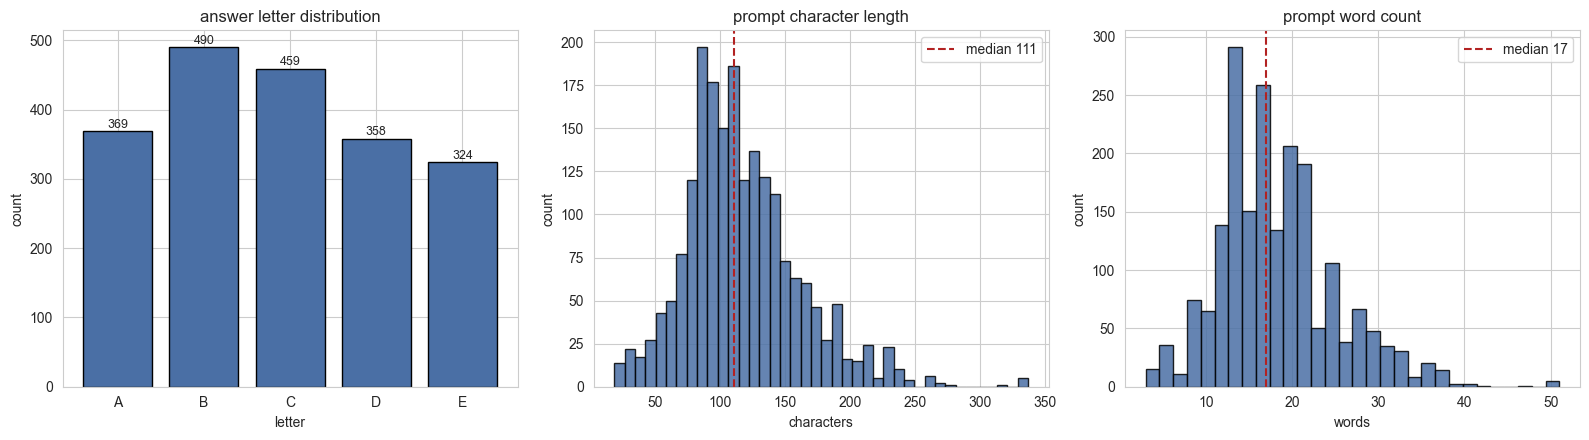

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ans_dist = train['answer'].value_counts().reindex(OPTIONS)
axes[0].bar(ans_dist.index, ans_dist.values, color='#4A6FA5', edgecolor='black')
axes[0].set_title('answer letter distribution')
axes[0].set_xlabel('letter'); axes[0].set_ylabel('count')
for i, v in enumerate(ans_dist.values):
    axes[0].text(i, v + 5, str(int(v)), ha='center', fontsize=9)

prompt_chars = train['prompt'].str.len()
axes[1].hist(prompt_chars, bins=40, color='#4A6FA5', edgecolor='black', alpha=0.85)
axes[1].axvline(prompt_chars.median(), color='#B22222', ls='--', label=f'median {int(prompt_chars.median())}')
axes[1].set_title('prompt character length')
axes[1].set_xlabel('characters'); axes[1].set_ylabel('count'); axes[1].legend()

prompt_words = train['prompt'].str.split().map(len)
axes[2].hist(prompt_words, bins=30, color='#4A6FA5', edgecolor='black', alpha=0.85)
axes[2].axvline(prompt_words.median(), color='#B22222', ls='--', label=f'median {int(prompt_words.median())}')
axes[2].set_title('prompt word count')
axes[2].set_xlabel('words'); axes[2].set_ylabel('count'); axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_distributions.png', dpi=110, bbox_inches='tight')
plt.show()

C:\Users\Krishna\AppData\Local\Temp\ipykernel_21064\1226708182.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(opt_lens, labels=OPTIONS)
C:\Users\Krishna\AppData\Local\Temp\ipykernel_21064\1226708182.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(opt_words, labels=OPTIONS)


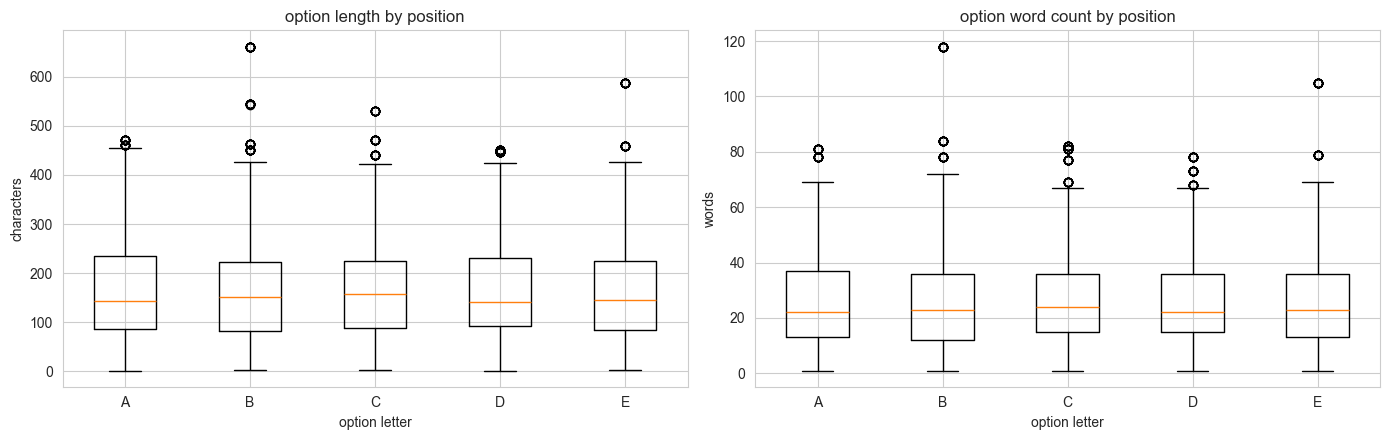

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
opt_lens = [train[L].astype(str).str.len().tolist() for L in OPTIONS]
axes[0].boxplot(opt_lens, labels=OPTIONS)
axes[0].set_title('option length by position')
axes[0].set_xlabel('option letter'); axes[0].set_ylabel('characters')

opt_words = [train[L].astype(str).str.split().map(len).tolist() for L in OPTIONS]
axes[1].boxplot(opt_words, labels=OPTIONS)
axes[1].set_title('option word count by position')
axes[1].set_xlabel('option letter'); axes[1].set_ylabel('words')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_option_position.png', dpi=110, bbox_inches='tight')
plt.show()

## Group B — Correctness patterns

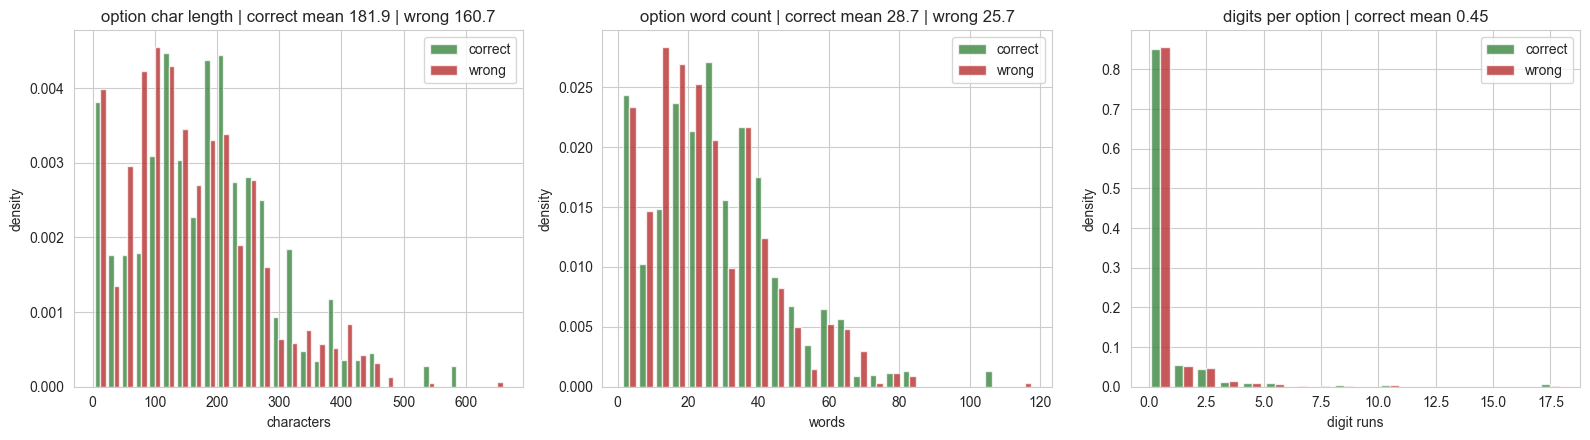

In [28]:
correct_chars, wrong_chars = [], []
correct_words, wrong_words = [], []
correct_digits, wrong_digits = [], []
for _, r in train.iterrows():
    for L in OPTIONS:
        text = str(r[L])
        target_chars = correct_chars if L == r['answer'] else wrong_chars
        target_words = correct_words if L == r['answer'] else wrong_words
        target_digits = correct_digits if L == r['answer'] else wrong_digits
        target_chars.append(len(text))
        target_words.append(len(text.split()))
        target_digits.append(len(re.findall(r'\d+', text)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist([correct_chars, wrong_chars], bins=30, label=['correct', 'wrong'],
             color=['#2E7D32', '#B22222'], alpha=0.75, density=True)
axes[0].set_title(f'option char length | correct mean {np.mean(correct_chars):.1f} | wrong {np.mean(wrong_chars):.1f}')
axes[0].set_xlabel('characters'); axes[0].set_ylabel('density'); axes[0].legend()

axes[1].hist([correct_words, wrong_words], bins=25, label=['correct', 'wrong'],
             color=['#2E7D32', '#B22222'], alpha=0.75, density=True)
axes[1].set_title(f'option word count | correct mean {np.mean(correct_words):.1f} | wrong {np.mean(wrong_words):.1f}')
axes[1].set_xlabel('words'); axes[1].set_ylabel('density'); axes[1].legend()

digit_max = max(max(correct_digits), max(wrong_digits))
bins = np.arange(0, digit_max + 2)
axes[2].hist([correct_digits, wrong_digits], bins=bins, label=['correct', 'wrong'],
             color=['#2E7D32', '#B22222'], alpha=0.75, density=True)
axes[2].set_title(f'digits per option | correct mean {np.mean(correct_digits):.2f}')
axes[2].set_xlabel('digit runs'); axes[2].set_ylabel('density'); axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_correctness_lengths.png', dpi=110, bbox_inches='tight')
plt.show()

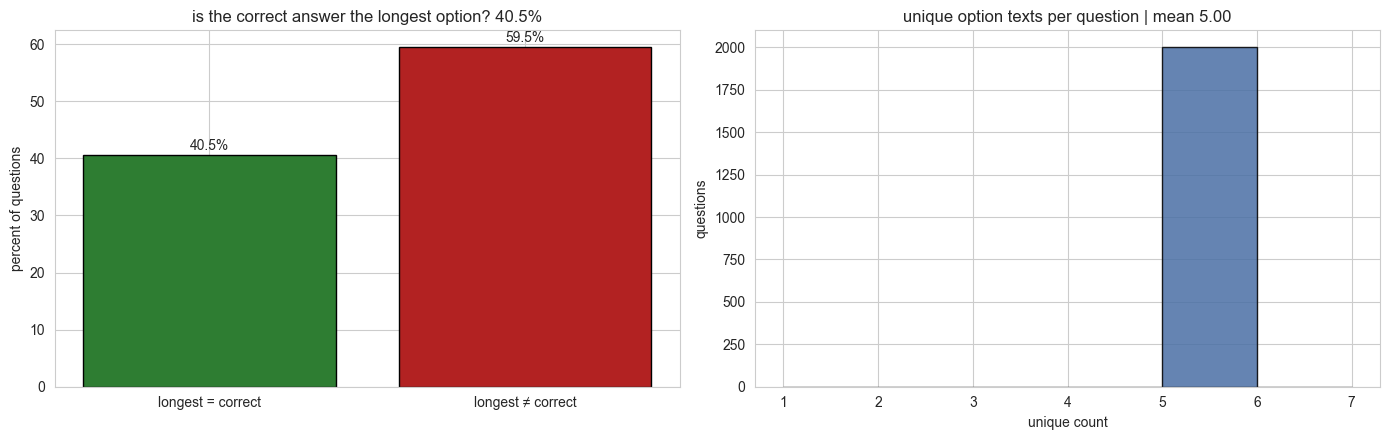

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

is_longest_hits = 0
for _, r in train.iterrows():
    lengths = {L: len(str(r[L])) for L in OPTIONS}
    longest = max(lengths, key=lengths.get)
    if longest == r['answer']:
        is_longest_hits += 1
pct = 100 * is_longest_hits / len(train)
axes[0].bar(['longest = correct', 'longest ≠ correct'], [pct, 100 - pct],
            color=['#2E7D32', '#B22222'], edgecolor='black')
axes[0].set_title(f'is the correct answer the longest option? {pct:.1f}%')
axes[0].set_ylabel('percent of questions')
for i, v in enumerate([pct, 100 - pct]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

unique_counts = train[OPTIONS].apply(lambda r: len(set(str(x).lower().strip() for x in r)), axis=1)
axes[1].hist(unique_counts, bins=range(1, 8), color='#4A6FA5', edgecolor='black', alpha=0.85)
axes[1].set_title(f'unique option texts per question | mean {unique_counts.mean():.2f}')
axes[1].set_xlabel('unique count'); axes[1].set_ylabel('questions')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_length_bias_and_uniqueness.png', dpi=110, bbox_inches='tight')
plt.show()

## Group C — Framing patterns and stem normalisation

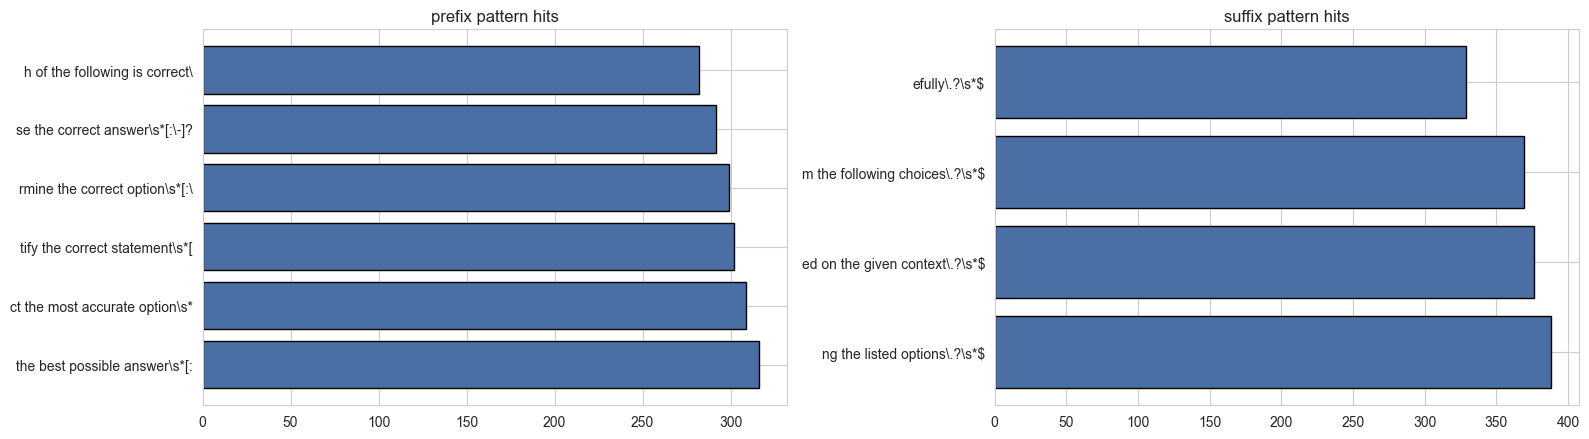

unique prompts train: 1758
unique stems train:   252
unique prompts test:  492
unique stems test:    228


In [30]:
PREFIX_PATTERNS = [
    r'^\s*pick the best possible answer\s*[:\-]?\s*',
    r'^\s*select the most accurate option\s*[:\-]?\s*',
    r'^\s*determine the correct option\s*[:\-]?\s*',
    r'^\s*identify the correct statement\s*[:\-]?\s*',
    r'^\s*choose the correct answer\s*[:\-]?\s*',
    r'^\s*which of the following is correct\??\s*',
]
SUFFIX_PATTERNS = [
    r'\s+based on the given context\.?\s*$',
    r'\s+based on the given information\.?\s*$',
    r'\s+from the following choices\.?\s*$',
    r'\s+among the listed options\.?\s*$',
    r'\s+carefully\.?\s*$',
    r'\s+above\.?\s*$',
]

def strip_framing(s):
    s = str(s)
    prev = None
    while prev != s:
        prev = s
        for p in PREFIX_PATTERNS:
            s = re.sub(p, '', s, flags=re.IGNORECASE)
        for p in SUFFIX_PATTERNS:
            s = re.sub(p, '', s, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', s).strip().lower()

train['stem'] = train['prompt'].apply(strip_framing)
test['stem'] = test['prompt'].apply(strip_framing)

prefix_matched = defaultdict(int)
suffix_matched = defaultdict(int)
for p in train['prompt']:
    ps = str(p).lower()
    for i, pat in enumerate(PREFIX_PATTERNS):
        if re.search(pat, ps, flags=re.IGNORECASE):
            prefix_matched[pat[8:38]] += 1
    for i, pat in enumerate(SUFFIX_PATTERNS):
        if re.search(pat, ps, flags=re.IGNORECASE):
            suffix_matched[pat[6:36]] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
if prefix_matched:
    labels, counts = zip(*sorted(prefix_matched.items(), key=lambda x: -x[1]))
    axes[0].barh(labels, counts, color='#4A6FA5', edgecolor='black')
    axes[0].set_title('prefix pattern hits')
if suffix_matched:
    labels, counts = zip(*sorted(suffix_matched.items(), key=lambda x: -x[1]))
    axes[1].barh(labels, counts, color='#4A6FA5', edgecolor='black')
    axes[1].set_title('suffix pattern hits')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_framing_patterns.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'unique prompts train: {train["prompt"].nunique()}')
print(f'unique stems train:   {train["stem"].nunique()}')
print(f'unique prompts test:  {test["prompt"].nunique()}')
print(f'unique stems test:    {test["stem"].nunique()}')

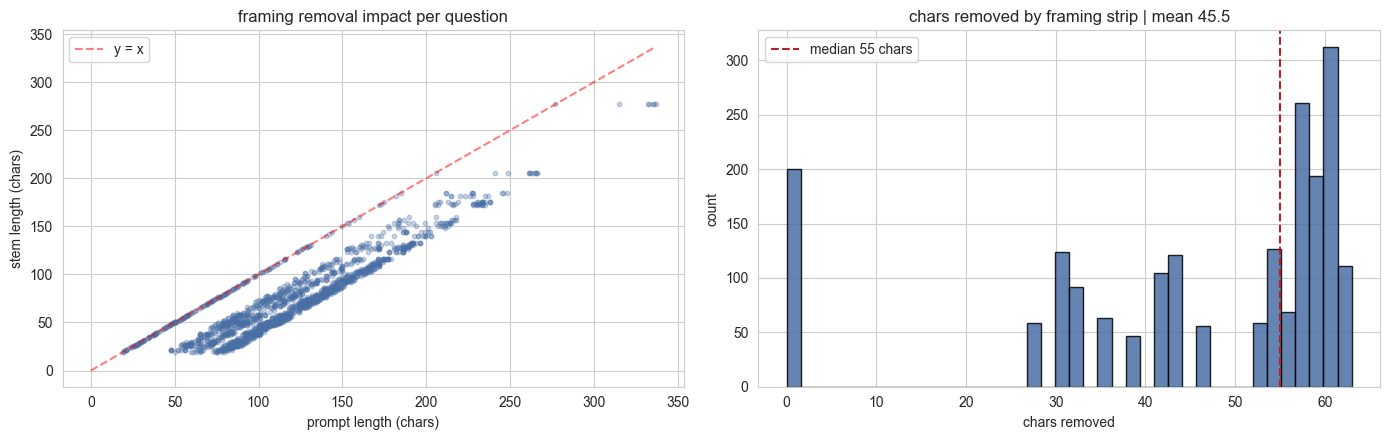

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
prompt_len = train['prompt'].str.len()
stem_len = train['stem'].str.len()
reduction = prompt_len - stem_len

axes[0].scatter(prompt_len, stem_len, alpha=0.3, s=10, color='#4A6FA5')
axes[0].plot([0, prompt_len.max()], [0, prompt_len.max()], 'r--', alpha=0.5, label='y = x')
axes[0].set_xlabel('prompt length (chars)'); axes[0].set_ylabel('stem length (chars)')
axes[0].set_title('framing removal impact per question')
axes[0].legend()

axes[1].hist(reduction, bins=40, color='#4A6FA5', edgecolor='black', alpha=0.85)
axes[1].axvline(reduction.median(), color='#B22222', ls='--', label=f'median {int(reduction.median())} chars')
axes[1].set_title(f'chars removed by framing strip | mean {reduction.mean():.1f}')
axes[1].set_xlabel('chars removed'); axes[1].set_ylabel('count'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_stem_reduction.png', dpi=110, bbox_inches='tight')
plt.show()

## Group D — Question-type flags

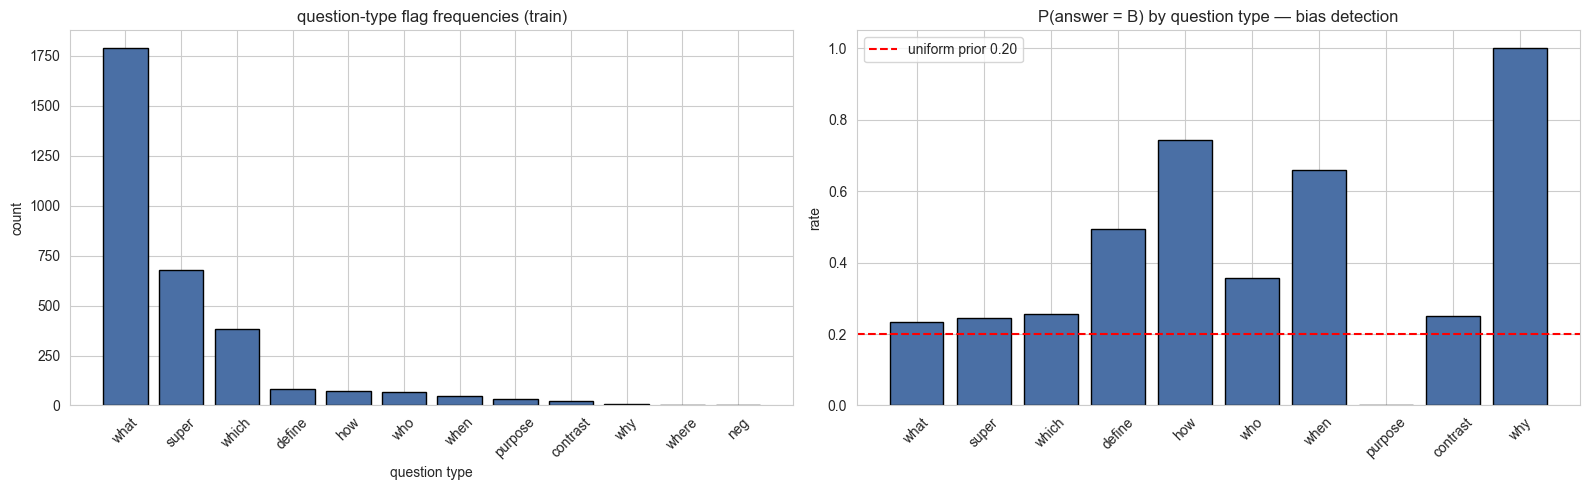

In [32]:
QTYPE_PATTERNS = {
    'q_what': r'\bwhat\b', 'q_who': r'\bwho\b', 'q_when': r'\bwhen\b',
    'q_where': r'\bwhere\b', 'q_why': r'\bwhy\b', 'q_how': r'\bhow\b',
    'q_which': r'\bwhich\b', 'q_define': r'\bdefin',
    'q_purpose': r'\bpurpose\b',
    'q_contrast': r'\bdifference|contrast|versus|compared',
    'q_neg': r'\bnot\b|except',
    'q_super': r'\bmost\b|best\b|primary\b|main\b|highest\b',
}

prompt_lower = train['prompt'].astype(str).str.lower()
qtype_counts = {}
for name, pat in QTYPE_PATTERNS.items():
    qtype_counts[name] = prompt_lower.str.contains(pat, regex=True).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sorted_types = sorted(qtype_counts.items(), key=lambda x: -x[1])
labels = [k.replace('q_', '') for k, _ in sorted_types]
counts = [v for _, v in sorted_types]
axes[0].bar(labels, counts, color='#4A6FA5', edgecolor='black')
axes[0].set_title('question-type flag frequencies (train)')
axes[0].set_xlabel('question type'); axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=45)

acc_by_type = {}
for name, pat in QTYPE_PATTERNS.items():
    hit = prompt_lower.str.contains(pat, regex=True)
    n_hit = hit.sum()
    if n_hit > 0:
        subset = train[hit]
        b_rate = (subset['answer'] == 'B').mean()
        acc_by_type[name.replace('q_', '')] = (b_rate, n_hit)

sorted_acc = sorted(acc_by_type.items(), key=lambda x: -x[1][1])
labels = [k for k, _ in sorted_acc]
rates = [v[0] for _, v in sorted_acc]
axes[1].bar(labels, rates, color='#4A6FA5', edgecolor='black')
axes[1].axhline(0.2, color='red', ls='--', label='uniform prior 0.20')
axes[1].set_title('P(answer = B) by question type — bias detection')
axes[1].set_ylabel('rate'); axes[1].tick_params(axis='x', rotation=45); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_question_types.png', dpi=110, bbox_inches='tight')
plt.show()

## Group E — Long-format transformation for downstream modeling

In [33]:
def to_long(df, has_ans=True):
    rows = []
    for _, r in df.iterrows():
        for L in OPTIONS:
            row = {'id': r['id'], 'prompt': r['prompt'], 'stem': r['stem'],
                   'option': str(r[L]), 'letter': L, 'letter_idx': OPTIONS.index(L)}
            if has_ans:
                row['is_correct'] = int(L == r['answer'])
            rows.append(row)
    return pd.DataFrame(rows)

train_long = to_long(train, True)
test_long = to_long(test, False)
print(f'train_long: {train_long.shape}, test_long: {test_long.shape}')

train_long: (10000, 7), test_long: (2500, 6)


## Group F — Handcrafted features

In [34]:
def add_prompt_flags(df):
    df = df.copy()
    prompt_lower = df['prompt'].astype(str).str.lower()
    for name, pat in QTYPE_PATTERNS.items():
        df[name] = prompt_lower.str.contains(pat, regex=True).astype(float)
    return df

def handcrafted(df):
    df = df.copy()
    df['opt_chars'] = df['option'].str.len().astype(float)
    df['opt_words'] = df['option'].str.split().map(len).astype(float)
    g = df.groupby('id')
    df['chars_ratio_max'] = df['opt_chars'] / g['opt_chars'].transform('max').clip(lower=1)
    df['chars_zscore'] = ((df['opt_chars'] - g['opt_chars'].transform('mean')) /
                          g['opt_chars'].transform('std').clip(lower=1e-6))
    df['chars_rank'] = g['opt_chars'].rank(ascending=False, method='min')
    df['words_ratio_max'] = df['opt_words'] / g['opt_words'].transform('max').clip(lower=1)
    df['is_longest'] = (df['opt_chars'] == g['opt_chars'].transform('max')).astype(float)
    df['is_shortest'] = (df['opt_chars'] == g['opt_chars'].transform('min')).astype(float)
    df['n_numbers'] = df['option'].apply(lambda s: len(re.findall(r'\d+', str(s)))).astype(float)
    df['n_commas'] = df['option'].str.count(',').astype(float)
    df['n_semi'] = df['option'].str.count(';').astype(float)
    df['has_not'] = df['option'].str.lower().str.contains(r'\bnot\b', regex=True).astype(float)
    df['has_except'] = df['option'].str.lower().str.contains(r'\bexcept\b', regex=True).astype(float)
    df['has_only'] = df['option'].str.lower().str.contains(r'\bonly\b', regex=True).astype(float)
    df['has_all'] = df['option'].str.lower().str.contains(r'\ball\b', regex=True).astype(float)
    df['has_none'] = df['option'].str.lower().str.contains(r'\bnone\b', regex=True).astype(float)
    df['starts_capital'] = df['option'].str.match(r'^[A-Z]').fillna(False).astype(float)
    df['position'] = df['letter_idx'].astype(float)
    return df

train_long = handcrafted(add_prompt_flags(train_long))
test_long = handcrafted(add_prompt_flags(test_long))
print(f'after handcrafted: {train_long.shape[1]} cols in train_long')

after handcrafted: 37 cols in train_long


## Group G — TF-IDF cosines

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

TFIDF_WORD_NGRAMS = (1, 3)
TFIDF_CHAR_NGRAMS = (3, 5)
LSA_DIM = 64
PCA_DIM = 32

corpus_texts = []
for L in OPTIONS:
    corpus_texts += train[L].astype(str).tolist()
    corpus_texts += test[L].astype(str).tolist()
corpus_texts += train['prompt'].astype(str).tolist()
corpus_texts += test['prompt'].astype(str).tolist()

tfidf_word = TfidfVectorizer(ngram_range=TFIDF_WORD_NGRAMS, min_df=1, max_features=120_000,
                              sublinear_tf=True, strip_accents='unicode')
tfidf_word.fit(corpus_texts)
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=TFIDF_CHAR_NGRAMS, min_df=1,
                              max_features=80_000, sublinear_tf=True)
tfidf_char.fit(corpus_texts)
print(f'word vocab: {len(tfidf_word.vocabulary_)}, char vocab: {len(tfidf_char.vocabulary_)}')

word vocab: 26536, char vocab: 23905


In [36]:
def add_tfidf_cos(df):
    p_w = tfidf_word.transform(df['prompt'].astype(str).tolist())
    o_w = tfidf_word.transform(df['option'].astype(str).tolist())
    pn = np.sqrt(np.asarray(p_w.multiply(p_w).sum(1)).ravel()).clip(min=1e-9)
    on = np.sqrt(np.asarray(o_w.multiply(o_w).sum(1)).ravel()).clip(min=1e-9)
    dot = np.asarray(p_w.multiply(o_w).sum(1)).ravel()
    df['tfidf_word_cos'] = dot / (pn * on)
    p_c = tfidf_char.transform(df['prompt'].astype(str).tolist())
    o_c = tfidf_char.transform(df['option'].astype(str).tolist())
    pcn = np.sqrt(np.asarray(p_c.multiply(p_c).sum(1)).ravel()).clip(min=1e-9)
    ocn = np.sqrt(np.asarray(o_c.multiply(o_c).sum(1)).ravel()).clip(min=1e-9)
    dotc = np.asarray(p_c.multiply(o_c).sum(1)).ravel()
    df['tfidf_char_cos'] = dotc / (pcn * ocn)
    return df

train_long = add_tfidf_cos(train_long)
test_long = add_tfidf_cos(test_long)

opt_char = tfidf_char.transform(train_long['option'].astype(str).tolist() +
                                test_long['option'].astype(str).tolist())
lsa = TruncatedSVD(n_components=LSA_DIM, random_state=SEED)
lsa_all = lsa.fit_transform(opt_char)
n_tr_long = len(train_long)
for i in range(LSA_DIM):
    train_long[f'lsa_{i}'] = lsa_all[:n_tr_long, i]
    test_long[f'lsa_{i}'] = lsa_all[n_tr_long:, i]
train_long = train_long.copy()
test_long = test_long.copy()
print(f'after tfidf + lsa: {train_long.shape[1]} cols in train_long')

after tfidf + lsa: 103 cols in train_long


## Group H — Sentence-transformer embeddings and cosines

In [37]:
import torch
from sentence_transformers import SentenceTransformer
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SBERT_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
sbert = SentenceTransformer(SBERT_MODEL, device=DEVICE)

train_prompt_embs = sbert.encode(train['prompt'].tolist(), batch_size=64,
                                  convert_to_numpy=True, normalize_embeddings=True,
                                  show_progress_bar=False)
test_prompt_embs = sbert.encode(test['prompt'].tolist(), batch_size=64,
                                 convert_to_numpy=True, normalize_embeddings=True,
                                 show_progress_bar=False)
train_opt_embs = sbert.encode(train_long['option'].tolist(), batch_size=128,
                               convert_to_numpy=True, normalize_embeddings=True,
                               show_progress_bar=False)
test_opt_embs = sbert.encode(test_long['option'].tolist(), batch_size=128,
                              convert_to_numpy=True, normalize_embeddings=True,
                              show_progress_bar=False)
print(f'prompt emb dim: {train_prompt_embs.shape[1]}, option emb dim: {train_opt_embs.shape[1]}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

prompt emb dim: 384, option emb dim: 384


In [38]:
NUM_CHOICES = 5
train_prompt_rep = np.repeat(train_prompt_embs, NUM_CHOICES, axis=0)
test_prompt_rep = np.repeat(test_prompt_embs, NUM_CHOICES, axis=0)
train_long['sbert_prompt_cos'] = np.sum(train_prompt_rep * train_opt_embs, axis=1)
test_long['sbert_prompt_cos'] = np.sum(test_prompt_rep * test_opt_embs, axis=1)

def sibling_cosines(embs):
    n = embs.shape[0]
    nq = n // NUM_CHOICES
    out = np.zeros(n)
    for i in range(nq):
        block = embs[i*NUM_CHOICES:(i+1)*NUM_CHOICES]
        for j in range(NUM_CHOICES):
            others = np.delete(block, j, axis=0)
            mean_others = others.mean(axis=0)
            mean_others = mean_others / (np.linalg.norm(mean_others) + 1e-9)
            out[i*NUM_CHOICES + j] = float(np.dot(block[j], mean_others))
    return out

train_long['sibling_sbert_cos'] = sibling_cosines(train_opt_embs)
test_long['sibling_sbert_cos'] = sibling_cosines(test_opt_embs)

pca = PCA(n_components=PCA_DIM, random_state=SEED)
all_opt = np.vstack([train_opt_embs, test_opt_embs])
pca_all = pca.fit_transform(all_opt)
for i in range(PCA_DIM):
    train_long[f'pca_{i}'] = pca_all[:len(train_opt_embs), i]
    test_long[f'pca_{i}'] = pca_all[len(train_opt_embs):, i]
train_long = train_long.copy()
test_long = test_long.copy()
print(f'after sbert + pca: {train_long.shape[1]} cols in train_long')

after sbert + pca: 137 cols in train_long


## Group I — Feature-vs-label overlays

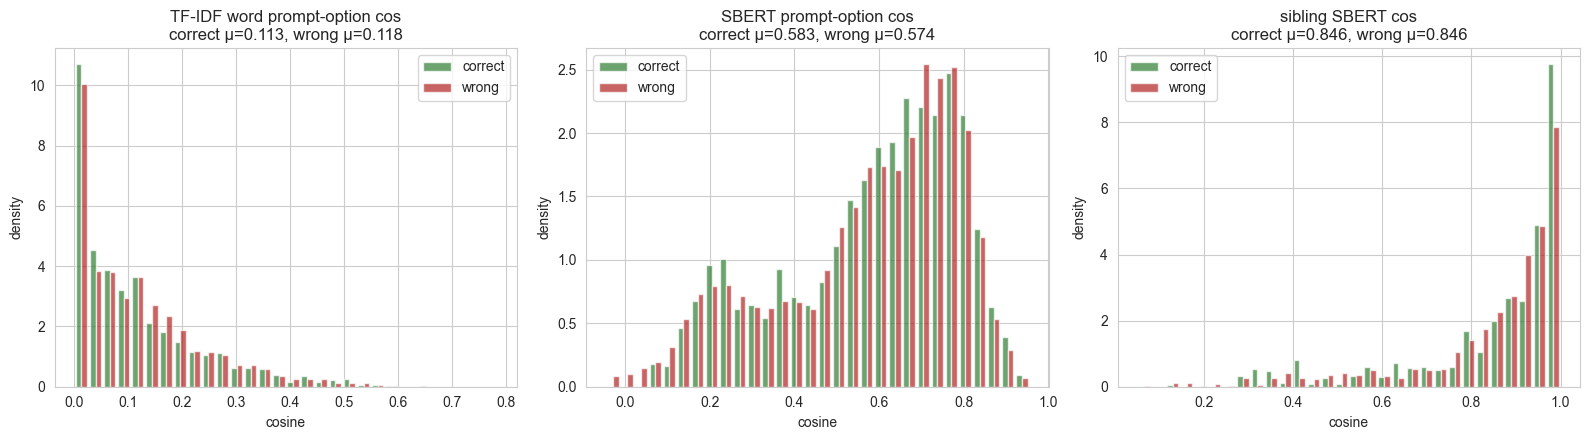

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(axes,
        ['tfidf_word_cos', 'sbert_prompt_cos', 'sibling_sbert_cos'],
        ['TF-IDF word prompt-option cos', 'SBERT prompt-option cos', 'sibling SBERT cos']):
    c = train_long.loc[train_long['is_correct'] == 1, col]
    w = train_long.loc[train_long['is_correct'] == 0, col]
    ax.hist([c, w], bins=30, label=['correct', 'wrong'], color=['#2E7D32', '#B22222'],
            alpha=0.7, density=True)
    ax.set_title(f'{title}\ncorrect μ={c.mean():.3f}, wrong μ={w.mean():.3f}')
    ax.set_xlabel('cosine'); ax.set_ylabel('density'); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_cosines_by_label.png', dpi=110, bbox_inches='tight')
plt.show()

## Group J — Feature correlation

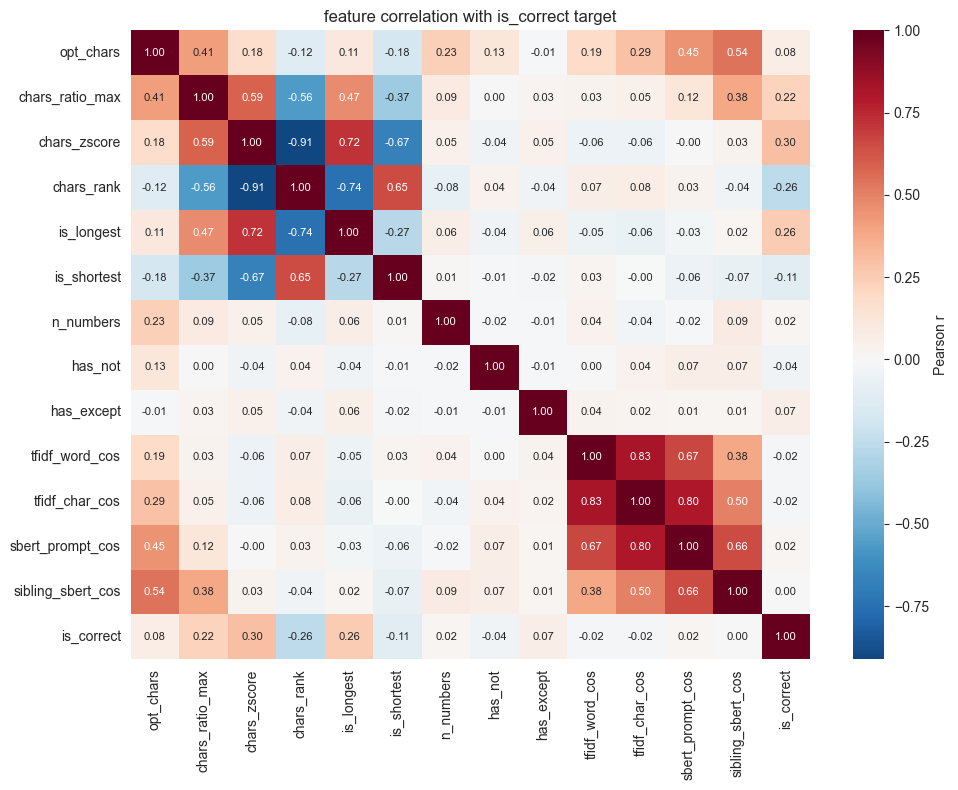

In [40]:
feat_subset = ['opt_chars', 'chars_ratio_max', 'chars_zscore', 'chars_rank',
               'is_longest', 'is_shortest', 'n_numbers', 'has_not', 'has_except',
               'tfidf_word_cos', 'tfidf_char_cos', 'sbert_prompt_cos', 'sibling_sbert_cos']
corr = train_long[feat_subset + ['is_correct']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Pearson r'}, annot_kws={'size': 8})
ax.set_title('feature correlation with is_correct target')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_feature_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

## Group K — GroupKFold assignment by stem

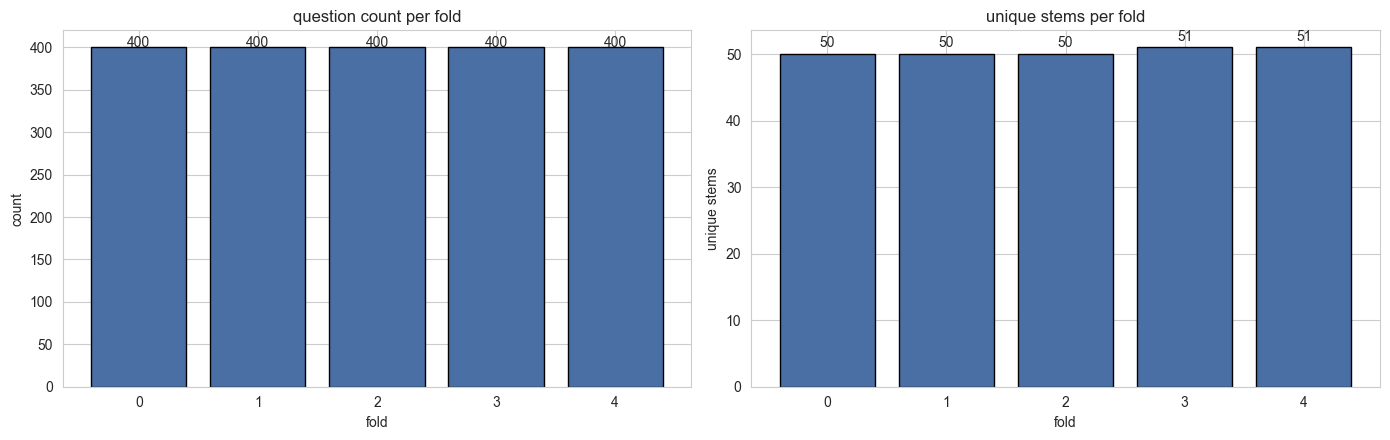

In [41]:
from sklearn.model_selection import GroupKFold
FOLDS = 5
gkf = GroupKFold(n_splits=FOLDS)
fold_of_id = np.zeros(len(train), dtype=int)
for fold, (_, val_idx) in enumerate(gkf.split(train, groups=train['stem'])):
    fold_of_id[val_idx] = fold
train['fold'] = fold_of_id
id_to_fold = dict(zip(train['id'], train['fold']))
train_long['fold'] = train_long['id'].map(id_to_fold)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fold_q_sizes = train.groupby('fold').size()
axes[0].bar(fold_q_sizes.index, fold_q_sizes.values, color='#4A6FA5', edgecolor='black')
axes[0].set_title('question count per fold')
axes[0].set_xlabel('fold'); axes[0].set_ylabel('count')
for i, v in enumerate(fold_q_sizes.values):
    axes[0].text(i, v + 1, str(int(v)), ha='center')

fold_stem_sizes = train.groupby('fold')['stem'].nunique()
axes[1].bar(fold_stem_sizes.index, fold_stem_sizes.values, color='#4A6FA5', edgecolor='black')
axes[1].set_title('unique stems per fold')
axes[1].set_xlabel('fold'); axes[1].set_ylabel('unique stems')
for i, v in enumerate(fold_stem_sizes.values):
    axes[1].text(i, v + 1, str(int(v)), ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_fold_composition.png', dpi=110, bbox_inches='tight')
plt.show()

## Group L — Save features and metadata for downstream notebooks

In [42]:
train_long.to_parquet(FEATURES_DIR / 'train_long.parquet', index=False)
test_long.to_parquet(FEATURES_DIR / 'test_long.parquet', index=False)
np.save(FEATURES_DIR / 'train_prompt_embs.npy', train_prompt_embs)
np.save(FEATURES_DIR / 'test_prompt_embs.npy', test_prompt_embs)
np.save(FEATURES_DIR / 'train_opt_embs.npy', train_opt_embs)
np.save(FEATURES_DIR / 'test_opt_embs.npy', test_opt_embs)

train[['id', 'fold', 'stem', 'answer']].to_parquet(FEATURES_DIR / 'train_meta.parquet', index=False)
test[['id', 'stem']].to_parquet(FEATURES_DIR / 'test_meta.parquet', index=False)

handcrafted_cols = [
    'opt_chars', 'opt_words', 'chars_ratio_max', 'chars_zscore', 'chars_rank',
    'words_ratio_max', 'is_longest', 'is_shortest', 'n_numbers', 'n_commas', 'n_semi',
    'has_not', 'has_except', 'has_only', 'has_all', 'has_none', 'starts_capital', 'position',
]
qtype_cols = list(QTYPE_PATTERNS.keys())
tfidf_cols = ['tfidf_word_cos', 'tfidf_char_cos']
sbert_cols = ['sbert_prompt_cos', 'sibling_sbert_cos']
lsa_cols = [f'lsa_{i}' for i in range(LSA_DIM)]
pca_cols = [f'pca_{i}' for i in range(PCA_DIM)]
FEAT_COLS = handcrafted_cols + qtype_cols + tfidf_cols + sbert_cols + lsa_cols + pca_cols

import json
with open(FEATURES_DIR / 'feat_cols.json', 'w') as f:
    json.dump({'FEAT_COLS': FEAT_COLS, 'handcrafted': handcrafted_cols,
               'qtype': qtype_cols, 'tfidf': tfidf_cols, 'sbert': sbert_cols,
               'lsa': lsa_cols, 'pca': pca_cols}, f, indent=2)

print(f'saved: train_long ({train_long.shape}), test_long ({test_long.shape})')
print(f'saved: prompt embs, option embs')
print(f'feat_cols total: {len(FEAT_COLS)}')

saved: train_long ((10000, 138)), test_long ((2500, 136))
saved: prompt embs, option embs
feat_cols total: 130
